In [117]:
#E perp B perp k
#no particles anywhere
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

u0 = 4*np.pi*1e-7
epsi0 = 8.854187817e-12
# c=1/np.sqrt(u0*epsi0)

c=1
L = 1.0
ng = 400
dx = L/ng
dt = 0.5*dx/c
t_tot = 2*L/c

In [118]:
x = np.linspace(0, L, ng, endpoint=False)
E0 = 1.0
x0 = L/2
sigma = 0.05

Ey = E0*np.exp(-((x-x0)**2)/(2*sigma**2))
Bz = np.zeros(ng)

In [119]:
def update_B(Ey,Bz):    #Faradays Law
    Bz_new = Bz.copy()
    for i in range(ng):
        Bz_new[i]+=(-dt/dx)*(Ey[(i+1)%ng]-Ey[i])
    return Bz_new

In [120]:
def update_E(Ey,Bz):        #Ampere's Law
    Ey_new=Ey.copy()
    for i in range(ng):
        Ey_new[i]+=c**2*(-dt/dx)*(Bz[i]-Bz[(i-1)%ng])
    return Ey_new

In [ ]:
t=0
Ey_hist = []
Bz_hist = []
while t<t_tot:
    Ey_hist.append(Ey.copy())
    Bz_hist.append(Bz.copy())
    Bz = update_B(Ey, Bz)
    Ey = update_E(Ey, Bz)
    t=t+dt

1601


In [122]:
print(np.max(Ey))
print(np.max(Bz))

0.9996535089659255
0.011749789288001855


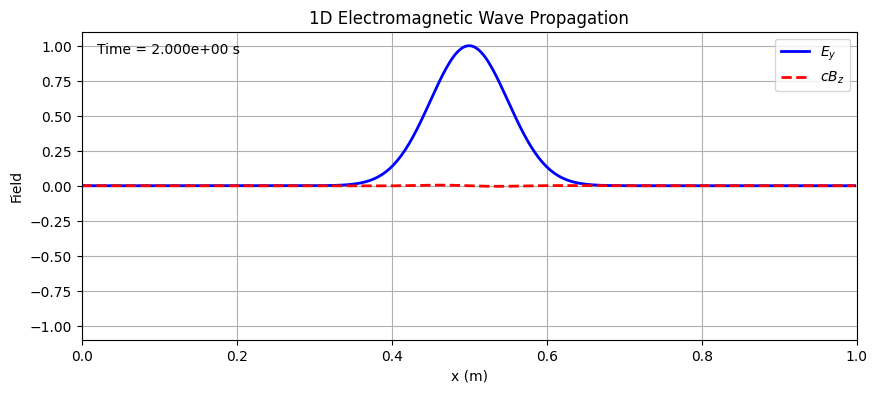

In [123]:
fig, ax = plt.subplots(figsize=(10,4))

lineE, = ax.plot([], [], 'b', lw=2, label=r'$E_y$')
lineB, = ax.plot([], [], 'r--', lw=2, label=r'$cB_z$')

ax.set_xlim(0, L)
ax.set_ylim(-1.1, 1.1)
ax.set_xlabel('x (m)')
ax.set_ylabel('Field')
ax.set_title('1D Electromagnetic Wave Propagation')
ax.grid(True)
ax.legend()

time_text = ax.text(0.02, 0.93, '', transform=ax.transAxes)

def init():
    lineE.set_data([], [])
    lineB.set_data([], [])
    time_text.set_text('')
    return lineE, lineB, time_text

def animate(i):
    lineE.set_data(x, Ey_hist[i])
    lineB.set_data(x, c*np.array(Bz_hist[i]))   # Plot cB so amplitudes are comparable

    time_text.set_text(f'Time = {i*dt:.3e} s')
    return lineE, lineB, time_text

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=len(Ey_hist),
    init_func=init,
    interval=30,
    blit=True
)
ani.save('Wave.mp4', writer='ffmpeg', fps=30)